In [260]:
!python -m spacy download fr_core_news_md

     ---------------------------------------- 0.0/45.8 MB ? eta -:--:--
     ---------------------------------------- 0.3/45.8 MB ? eta -:--:--
      --------------------------------------- 1.0/45.8 MB 3.5 MB/s eta 0:00:13
     -- ------------------------------------- 2.9/45.8 MB 5.9 MB/s eta 0:00:08
     ---- ----------------------------------- 5.0/45.8 MB 7.3 MB/s eta 0:00:06
     ------ --------------------------------- 7.3/45.8 MB 8.1 MB/s eta 0:00:05
     -------- ------------------------------- 9.4/45.8 MB 8.5 MB/s eta 0:00:05
     ---------- ----------------------------- 11.5/45.8 MB 8.7 MB/s eta 0:00:04
     ----------- ---------------------------- 13.1/45.8 MB 8.7 MB/s eta 0:00:04
     ------------- -------------------------- 15.2/45.8 MB 8.9 MB/s eta 0:00:04
     --------------- ------------------------ 17.8/45.8 MB 9.1 MB/s eta 0:00:04
     ------------------ --------------------- 21.0/45.8 MB 9.7 MB/s eta 0:00:03
     -------------------- ------------------- 23.1/45.8 MB 9.

In [261]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import numpy as np
import spacy 
import re 
from tqdm import tqdm
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters


In [262]:
from scipy.stats import mannwhitneyu


In [402]:

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


L'objectif de ce notebook est d'analyser la vérifiabilité dans le discours politique. Nous avons labellisé 1000 extraits de programmes des législatives de 1990. 

Chaque extrait de texte est associé à 3 variables: 
- le parti politique 
- l'orientation politique (gauche radicale, gauche, centre, droite, droite radicale, indépendants)
- la vérifiabilité/le du contenu du texte: par exemple, un candidat qui affirme qu'il souhaite "augmenter le budget de l'éducation nationale de 15% et d'accroitre le volume horaire d'education morale et civique" sera classé comme vérifiable (label 0) tandis qu'un candidat qui affirme vouloir "donner plus d'importance à l'éducation nationale" sera classé comme non-vérifiable (label 1).

# I- Data exploration

## 1) Divergences d'annotations

On commence par comparer les annotations réalisées par les 3 membres du groupe sur un sous ensemble de 200 textes. On va calculer le Kappa de Fleiss pour s'assurer qu'il n'y a pas trop de désaccords sur la façon dont les labels sont assignés.

In [301]:
df = pd.read_excel("annotations communes.xlsx")

ratings = df[["Annotations JL", "Annotations Henri", "Annotations Julien"]].values

table_comptage, categories = aggregate_raters(ratings)

#computing fleiss kappa score
kappa = fleiss_kappa(table_comptage, method='fleiss')

print(f"Number of texts : {len(df)}")
print(f"Fleiss Kappa : {kappa:.4f}")

Number of texts : 199
Fleiss Kappa : 0.8681


On a un Kappa de Fleiss de 0.87%, ce qui est très robuste et nous assure qu'il n'y a pas trop de divergences d'annotations entre les 3 annotateurs. 

On va aussi comparer la proportion de 0 et de 1 par annotateur sur les 200 annotations communes et sur les datasets annotés spécifiquement par un annotateur:

In [302]:
print("Proportions de 1 chez Henri dans le dataset d'annotations communes:", np.round(df[["Annotations Henri"]].mean(),2))
print("Proportions de 1 chez Julien dans le dataset d'annotations communes:", np.round(df[["Annotations Julien"]].mean(),2))
print("Proportions de 1 chez JL dans le dataset d'annotations communes:", np.round(df[["Annotations JL"]].mean(),2))

Proportions de 1 chez Henri dans le dataset d'annotations communes: Annotations Henri    0.66
dtype: float64
Proportions de 1 chez Julien dans le dataset d'annotations communes: Annotations Julien    0.61
dtype: float64
Proportions de 1 chez JL dans le dataset d'annotations communes: Annotations JL    0.67
dtype: float64


In [341]:
df_henri = pd.read_excel("annotations Henri.xlsx")
df_julien = pd.read_excel("annotations Julien.xlsx")
df_jl = pd.read_excel("annotations JL.xlsx")

print("Proportions de 1 chez Henri dans son dataset d'annotation:", np.round(df_henri[["LDB"]].mean(),2))
print("Proportions de 1 chez Julien dans son dataset d'annotation:", np.round(df_julien[["LDB"]].mean(),2))
print("Proportions de 1 chez JL dans son dataset d'annotation:", np.round(df_jl[["LDB"]].mean(),2))

Proportions de 1 chez Henri dans son dataset d'annotation: LDB    0.74
dtype: float64
Proportions de 1 chez Julien dans son dataset d'annotation: LDB    0.65
dtype: float64
Proportions de 1 chez JL dans son dataset d'annotation: LDB    0.69
dtype: float64


Les proportions sont très stables entre annotateurs, ce qui est satisfaisant et devrait nous rassurer quant au risque de biais dans les annotations.

## 2) Traitement des données et création de features

In [342]:
df_henri['source_annotation'] = 'Henri'
df_jl['source_annotation'] = 'JL'
df_julien['source_annotation'] = 'Julien'

df_master = pd.concat([df_henri, df_jl, df_julien], ignore_index=True)

taille_avant = len(df_master)
df_master = df_master.drop_duplicates(subset=['Texte'], keep='first')
taille_apres = len(df_master)

if taille_avant != taille_apres:
    print(f"Attention : {taille_avant - taille_apres} textes doublons supprimés.")

Attention : 9 textes doublons supprimés.


In [343]:
df_master.columns = ['Parti', 'Courant Politique', 'Texte', 'Label', 'source_annotation']

On va maintenant nettoyer le texte et ajouter des features:
- suppression des retours à la lignes, des puces, des tirets de liste
- lemmatisation du texte pour éviter que "franc" et "francs" soient des mots identiques
- détection des entités nommées 
- split en datasets de train et de test et validation 
- sur chaque dataset, on regarde pour chaque classe 0 et 1 quels sont les mots les plus fréquents (pas sur le dataset global pour éviter le data leakage). On ne considère pas l'intersection entre les deux dictionnaires de mots les plus fréquents. 
- on construit des features à partir du texte:
    - ratio de valeurs numériques dans le texte
    - ratio d'entités institutionnles dans le texte 
    - ratio de concretude lexicale: pour un texte donné, c'est le nb de mots fréquents de la classe 0/nb de mots fréquents dans les deux classes 
    - ratio de nominalisation: ratio de mots se finissant par des suffixes d'abstraction de type "-tion, -ité, -isme, -ment"
    - ratio de verbes au futur et au conditionnel / nb total de verbes
    - ratio d'interpellation: nb de pronoms d'interpellation (nous, vous, notre, votre)/ nb total de pronoms
    - ratio d'emphase: nb d'adjectifs + adverbes/nb de verbes 
    - longueur moyenne des phrases 
    - nb d'éléments de ponctuation / nb de phrases 

On définit ci dessous les fonctions qui nous permettent de faire ça:

In [344]:
nlp = spacy.load("fr_core_news_md")

def extraire_toutes_features(texte):
    """
    Nettoie le texte, extrait les entités (NER), génère la lemmatisation,
    et calcule les features stylistiques et morphosyntaxiques.
    """
    # Valeurs par défaut si le texte est vide
    if pd.isna(texte) or str(texte).strip() == "":
        return pd.Series({
            "texte_lemmatise": "", "nb_valeurs_numeriques": 0, 
            "nb_entites_institutionnelles": 0, "densite_ner": 0.0,
            "densite_nominalisation": 0.0, "ratio_futur_cond": 0.0,
            "ratio_interpellation": 0.0, "ratio_emphase": 0.0,
            "mots_par_phrase": 0.0, "densite_ponct_interne": 0.0
        })
    
    # Nettoyage OCR
    texte_clean = re.sub(r'-\s*\n\s*', '', str(texte))
    texte_clean = re.sub(r'[·\-\_\r\n]+', ' ', texte_clean)
    texte_clean = re.sub(r'\s+', ' ', texte_clean).strip()
    
    doc = nlp(texte_clean)
    
    # --- Variables globales d'initialisation ---
    lemmes = []
    longueur_mots = 0
    nb_noms_abstraits = 0
    nb_verbes_total = 0
    nb_verbes_futur_cond = 0
    nb_pronoms_total = 0
    nb_pronoms_interpellation = 0
    nb_adj_adv = 0
    nb_ponct_interne = 0
    
    # Listes de détection sémantique
    mots_interpellation = {"nous", "vous", "notre", "votre", "nos", "vos"}
    suffixes_abstraits = ("tion", "tions", "ité", "ités", "isme", "ismes", "ment", "ments")
    ponctuation_interne = {",", ";", ":"}

    # --- 1. Features Sémantiques (NER) ---
    nb_valeurs_numeriques = sum(1 for token in doc if token.pos_ == "NUM")
    nb_entites_institutionnelles = sum(1 for ent in doc.ents if ent.label_ in ["LOC", "ORG"])
    
    # --- 2. Boucle Morphosyntaxique Principale ---
    for token in doc:
        # Ponctuation interne (Feature E)
        if token.text in ponctuation_interne:
            nb_ponct_interne += 1
            
        # Comptage des vrais mots et lemmatisation
        if not token.is_punct and not token.is_space:
            longueur_mots += 1
            
            if not token.is_stop and len(token.lemma_) > 1:
                lemmes.append(token.lemma_.lower())
                
            # --- Feature A : Nominalisation ---
            if token.pos_ == "NOUN" and token.text.lower().endswith(suffixes_abstraits):
                nb_noms_abstraits += 1
                
            # --- Feature B : Verbes et Temps ---
            if token.pos_ in ["VERB", "AUX"]:
                nb_verbes_total += 1
                # Extraction des traits morphologiques
                tense = token.morph.get("Tense")
                mood = token.morph.get("Mood")
                if "Fut" in tense or "Cnd" in mood:
                    nb_verbes_futur_cond += 1
                    
            # --- Feature C : Interpellation ---
            if token.pos_ in ["PRON", "DET"]:
                nb_pronoms_total += 1
                if token.text.lower() in mots_interpellation:
                    nb_pronoms_interpellation += 1
                    
            # --- Feature D : Emphase ---
            if token.pos_ in ["ADJ", "ADV"]:
                nb_adj_adv += 1

    # --- 3. Découpage en phrases (Feature E) ---
    # Convertir le générateur en liste pour compter les phrases
    nb_phrases = len(list(doc.sents)) 

    # --- Sécurités anti division par zéro ---
    if longueur_mots == 0: longueur_mots = 1
    if nb_verbes_total == 0: nb_verbes_total = 1
    if nb_pronoms_total == 0: nb_pronoms_total = 1
    if nb_phrases == 0: nb_phrases = 1

    # --- Renvoi de la ligne de données ---
    return pd.Series({
        "texte_lemmatise": " ".join(lemmes),
        "densite_valeurs_numeriques": nb_valeurs_numeriques / longueur_mots,
        "densite_entites_institutionnelles": nb_entites_institutionnelles / longueur_mots,
        "densite_nominalisation": nb_noms_abstraits / longueur_mots,
        "densite_futur_cond": nb_verbes_futur_cond / longueur_mots,
        "densite_interpellation": nb_pronoms_interpellation / longueur_mots,
        "densite_emphase": nb_adj_adv / longueur_mots,
        "mots_par_phrase": longueur_mots / nb_phrases,
        "densite_ponct_interne": nb_ponct_interne / longueur_mots
    })

# --- ETAPE 2 : EXTRACTION DU VOCABULAIRE DISCRIMINANT ---

def extraire_vocabulaire_contrastif(df_train, top_n=30):
    textes_0 = df_train[df_train['Label'] == 0]['texte_lemmatise'].dropna()
    textes_1 = df_train[df_train['Label'] == 1]['texte_lemmatise'].dropna()
    
    vectorizer = CountVectorizer(ngram_range=(1, 2), min_df=2)
    
    def get_top_words(textes):
        matrice = vectorizer.fit_transform(textes)
        somme = matrice.sum(axis=0)
        mots = [(mot, somme[0, idx]) for mot, idx in vectorizer.vocabulary_.items()]
        return set([mot for mot, freq in sorted(mots, key=lambda x: x[1], reverse=True)[:top_n]])
    
    top_mots_0 = get_top_words(textes_0)
    top_mots_1 = get_top_words(textes_1)
    
    intersection = top_mots_0.intersection(top_mots_1)
    return top_mots_0 - intersection, top_mots_1 - intersection,intersection

# --- ETAPE 3 : FABRICATION DES FEATURES LEXICALES ---

def appliquer_features_lexicales(df, vocab_0, vocab_1):
    def compter_mots(texte, vocabulaire):
        if not isinstance(texte, str): return 0
        return sum(1 for mot in texte.split() if mot in vocabulaire)
    
    df['nb_termes_classe_0'] = df['texte_lemmatise'].apply(lambda x: compter_mots(x, vocab_0))
    df['nb_termes_classe_1'] = df['texte_lemmatise'].apply(lambda x: compter_mots(x, vocab_1))
    
    df['ratio_concretude_lexicale'] = df.apply(
        lambda row: row['nb_termes_classe_0'] / (row['nb_termes_classe_0'] + row['nb_termes_classe_1']) 
        if (row['nb_termes_classe_0'] + row['nb_termes_classe_1']) > 0 else 0.5, 
        axis=1
    )
    return df

On peut ensuite appliquer ces fonctions à notre corpus de texte:

In [345]:
tqdm.pandas()
colonnes_extraites = [ "texte_lemmatise",
    "densite_valeurs_numeriques",
        "densite_entites_institutionnelles",
        "densite_nominalisation",
        "densite_futur_cond",
        "densite_interpellation",
        "densite_emphase",
        "mots_par_phrase",
        "densite_ponct_interne"
]

df_master[colonnes_extraites] = df_master['Texte'].progress_apply(extraire_toutes_features)


100%|██████████| 957/957 [00:17<00:00, 56.17it/s]


In [346]:
df_master[colonnes_extraites]

,texte_lemmatise,densite_valeurs_numeriques,densite_entites_institutionnelles,densite_nominalisation,densite_futur_cond,densite_interpellation,densite_emphase,mots_par_phrase,densite_ponct_interne
0,arrêter accroissement pression fiscal,0.000000,0.000000,0.142857,0.000000,0.000000,0.142857,7.00,0.000000
1,gauche an mitterrand trahir engager ment nom g...,0.012048,0.024096,0.048193,0.000000,0.000000,0.120482,20.75,0.096386
2,bourrer crâne compétitivité crise réalité diri...,0.000000,0.000000,0.089286,0.000000,0.017857,0.053571,56.00,0.089286
3,fermeture hoover bendix montrer patron agir ba...,0.000000,0.000000,0.035714,0.000000,0.035714,0.071429,28.00,0.071429
4,politiciens disent société gérer profit non in...,0.000000,0.016667,0.000000,0.016667,0.050000,0.183333,10.00,0.016667
...,...,...,...,...,...,...,...,...,...
961,france signer convention européen langue minor...,0.000000,0.047619,0.095238,0.000000,0.000000,0.190476,21.00,0.047619
962,reconnaître officiellement langue breton acte ...,0.000000,0.000000,0.041667,0.000000,0.000000,0.208333,12.00,0.000000
963,créer service public breton breton radio télév...,0.000000,0.050000,0.050000,0.000000,0.000000,0.150000,20.00,0.000000
964,ambition alternative france concevoir europe i...,0.000000,0.227273,0.045455,0.000000,0.045455,0.090909,22.00,0.090909


In [347]:
#stratify pour conserver les memes proportions de classe das train et test
df_train, df_test = train_test_split(df_master, test_size=0.2, random_state=42, stratify=df_master['Label'])


In [348]:
vocab_0, vocab_1,intersection = extraire_vocabulaire_contrastif(df_train, top_n=60)

In [349]:
print("vocabularie fréquent dans classe 0",vocab_0)
print("vocabularie fréquent dans classe 1",vocab_1)
print("vocabulaire fréquent dans les deux classes",intersection)

vocabularie fréquent dans classe 0 {'créer', 'activité', 'droit', 'taux', 'plus', 'développer', 'intérêt', 'etat', 'européen', 'rural', 'agriculture', 'loi', 'protection', 'heure', 'quartier', 'retraite', 'impôt', 'défense', 'projet', 'salaire', '000', 'milliard', 'moyen', 'service', 'revenu', 'temps', 'sécurité', 'plan', 'charge', 'million', 'création', 'permettre', 'chômeur', 'logement', 'local', 'formation', 'espace'}
vocabularie fréquent dans classe 1 {'aujourd hui', 'aujourd', '21', 'circonscription', 'solidarité', 'gauche', 'confiance', 'tour', 'ensemble', 'action', 'vouloir', 'besoin', 'monsieur', 'développement', 'socialiste', 'candidat', 'prendre', 'homme', 'donner', 'parti', 'mars', 'citoyen', 'défendre', 'hui', 'avenir', 'bien', 'député', 'monde', 'avoir', 'société', 'économique', 'écologiste', 'communiste', 'progrès', 'force', 'voter', 'jeune'}
vocabulaire fréquent dans les deux classes {'politique', 'travail', 'vie', 'public', 'environnement', 'pays', 'grand', 'être', 'fai

In [350]:
df_train = appliquer_features_lexicales(df_train, vocab_0, vocab_1)
df_test = appliquer_features_lexicales(df_test, vocab_0, vocab_1)


In [351]:
df_train['ratio_concretude_lexicale']

222    0.000000
815    1.000000
887    0.333333
604    0.000000
769    0.000000
         ...   
355    0.333333
425    0.500000
811    0.500000
400    1.000000
683    0.000000
Name: ratio_concretude_lexicale, Length: 765, dtype: float64

## C) Worldcloud

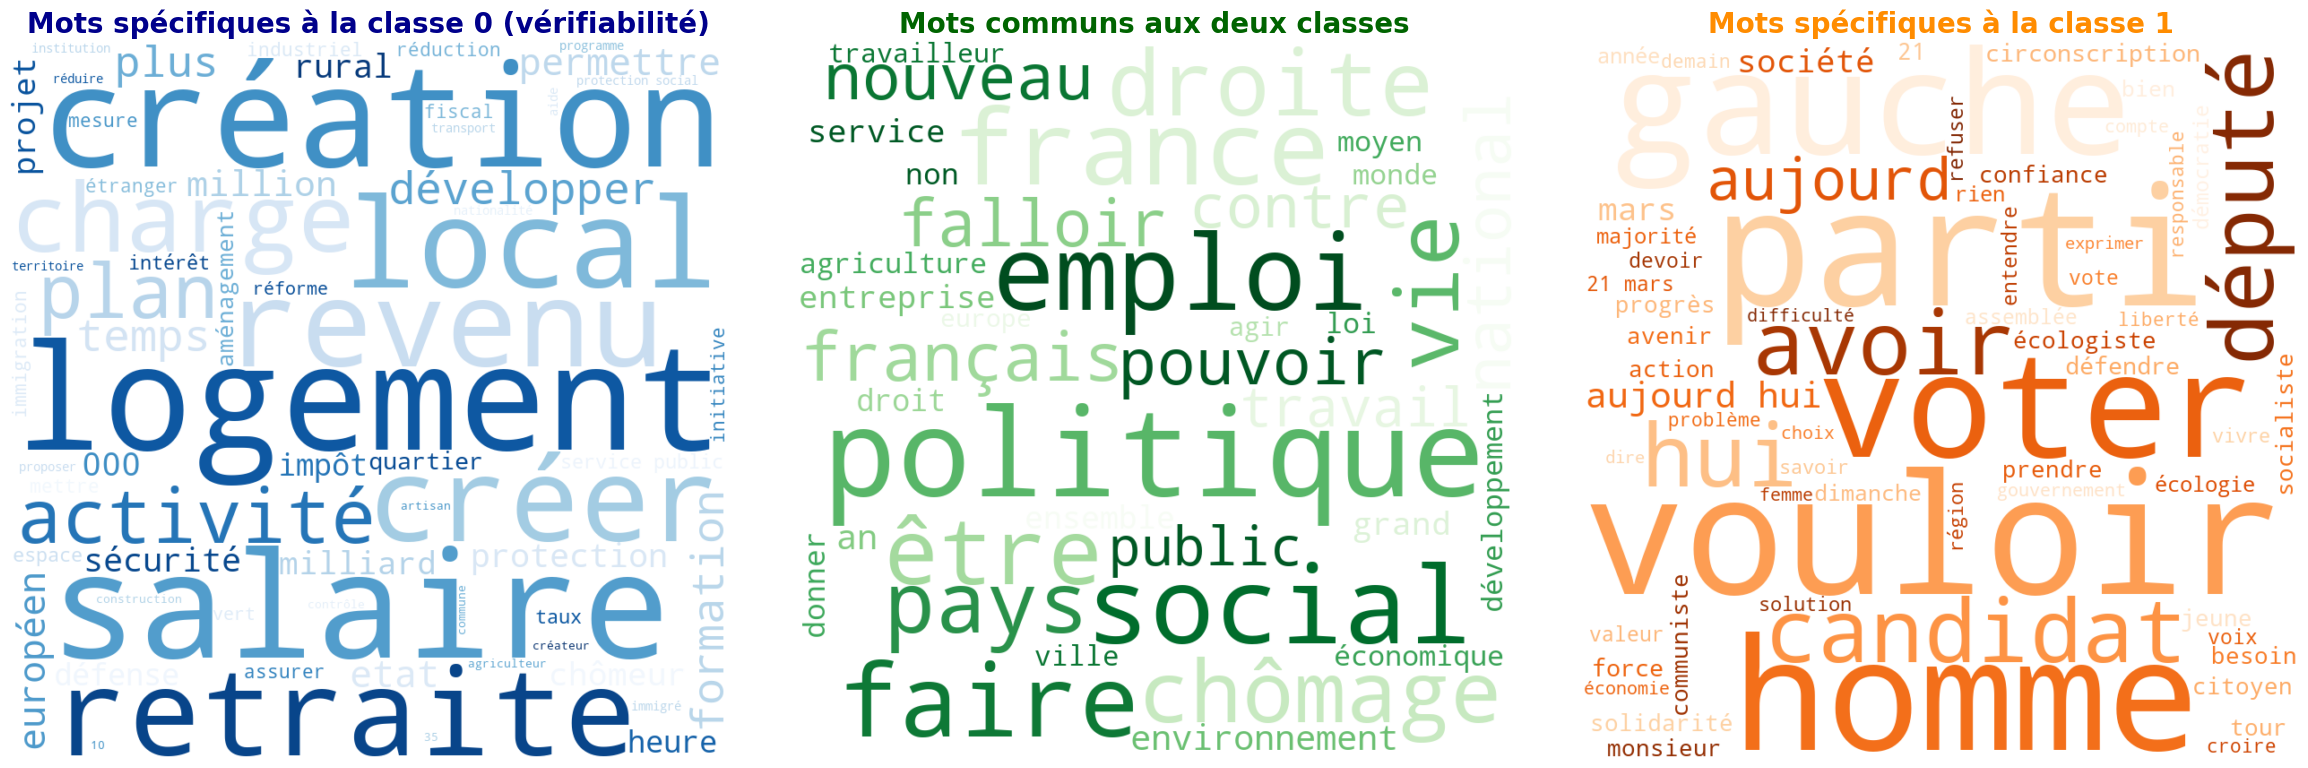

In [352]:
def plot_wordclouds_contrastifs(df, top_n=80):
    """
    Génère 3 wordclouds : Classe 0 pure, Intersection, et Classe 1 pure.
    Basé sur l'extraction mathématique des fréquences.
    """
    # 1. Séparation des textes par classe
    textes_0 = df[df['Label'] == 0]['texte_lemmatise'].dropna()
    textes_1 = df[df['Label'] == 1]['texte_lemmatise'].dropna()

    # 2. Vectorisation pour obtenir les fréquences réelles (incluant les bigrammes)
    vectorizer_0 = CountVectorizer(ngram_range=(1, 2), min_df=2)
    matrice_0 = vectorizer_0.fit_transform(textes_0)
    freq_0 = dict(zip(vectorizer_0.get_feature_names_out(), matrice_0.sum(axis=0).A1))

    vectorizer_1 = CountVectorizer(ngram_range=(1, 2), min_df=2)
    matrice_1 = vectorizer_1.fit_transform(textes_1)
    freq_1 = dict(zip(vectorizer_1.get_feature_names_out(), matrice_1.sum(axis=0).A1))

    # 3. Isolation des Tops N pour chaque classe
    top_mots_0 = set(sorted(freq_0, key=freq_0.get, reverse=True)[:top_n])
    top_mots_1 = set(sorted(freq_1, key=freq_1.get, reverse=True)[:top_n])

    # 4. Calculs des ensembles
    intersection = top_mots_0.intersection(top_mots_1)
    
    # 5. Création des dictionnaires de fréquences filtrés
    # Classe 0 pure (on garde sa fréquence d'origine, mais on exclut l'intersection)
    dict_pure_0 = {mot: freq_0[mot] for mot in top_mots_0 if mot not in intersection}
    
    # Classe 1 pure
    dict_pure_1 = {mot: freq_1[mot] for mot in top_mots_1 if mot not in intersection}
    
    # Intersection (pour la taille du mot, on prend la moyenne de sa fréquence dans les 2 classes)
    dict_inter = {mot: (freq_0[mot] + freq_1[mot]) / 2 for mot in intersection}

    # Sécurité au cas où l'intersection serait vide (peu probable mais bonne pratique)
    if not dict_inter: dict_inter = {"AUCUN_MOT_COMMUN": 1}
    if not dict_pure_0: dict_pure_0 = {"AUCUN_MOT_SPECIFIQUE": 1}
    if not dict_pure_1: dict_pure_1 = {"AUCUN_MOT_SPECIFIQUE": 1}

    # --- 6. Affichage des 3 WordClouds ---
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    # Paramètres de base communs
    wc_params = {'width': 800, 'height': 800, 'background_color': 'white'}

    # A. Classe 0 Pure
    wc_0 = WordCloud(**wc_params, colormap='Blues').generate_from_frequencies(dict_pure_0)
    axes[0].imshow(wc_0, interpolation='bilinear')
    axes[0].set_title(f"Mots spécifiques à la classe 0 (vérifiabilité)", fontsize=20, fontweight='bold', color='darkblue')
    axes[0].axis('off')

    # B. L'Intersection
    wc_inter = WordCloud(**wc_params, colormap='Greens').generate_from_frequencies(dict_inter)
    axes[1].imshow(wc_inter, interpolation='bilinear')
    axes[1].set_title(f"Mots communs aux deux classes", fontsize=20, fontweight='bold', color='darkgreen')
    axes[1].axis('off')

    # C. Classe 1 Pure
    wc_1 = WordCloud(**wc_params, colormap='Oranges').generate_from_frequencies(dict_pure_1)
    axes[2].imshow(wc_1, interpolation='bilinear')
    axes[2].set_title(f"Mots spécifiques à la classe 1", fontsize=20, fontweight='bold', color='darkorange')
    axes[2].axis('off')

    # Ajustement visuel global
    plt.tight_layout(pad=3.0)
    plt.show()

# Exécution de la fonction sur le set d'entraînement
plot_wordclouds_contrastifs(df_train, top_n=100)

Les trois wordclouds ci dessus sont très satisfaisants et confirment que notre travail de labelisation est plutôt convaincant: 

- les mots de la classe 0 (contenu vérifiable des professions de foi) sont associés à un lexique de gestion, d'adiministration, de quantification: on y retrouve:
    - des variables quantitatives: salaire, revenu, impôt, 000, heure, million, taux ...
    - associés à l'espace et à l'administration: logement, local, rural, état, territoire...
    - des noms communs et des verbes liés à l'action de l'Etat: création, créer, activité, réforme, projet, proposer, aménagement, construction,...

- dans la classe 1, on retrouve des termes du discours éléctoral, parlant de l'élection elle même plutôt que du programme: on y retrouve
    - des mots du vocabulaire politique non spécifiques à un programme: on a pu observer pendant la phase de labellisation que ces mots sont en général associés aux introductions de programmes, aux conclusions des professions de foi, etc: voter, parti, candidat, société, démocratie, dimanche 21 mars (jour de l'élection), socialiste, communiste,...
    - des mots associés aux valeurs, et plus généralement à des concepts vagues impossibles à quantifier: solidarité, solution, progrès, confiance, ...
    - des verbes modaux d'intention: vouloir, avoir, devoir,..

- dans les mots fréquents dans les deux classes, on retrouve des themes centraux de la campagne, comme chomage, emploi, pays, environnement, travail, etc. Cela montre que ces thèmes sont abordés aussi bien dans la classe 0 que dans la classe 1, et que ce qui différencie les deux classes, c'est la façon dont on aborde ces termes, soit de façon réthorique, soit de façon "quantitative".

## D) Boxplots

In [353]:
df_train.columns

Index(['Parti', 'Courant Politique', 'Texte', 'Label', 'source_annotation',
       'texte_lemmatise', 'densite_valeurs_numeriques',
       'densite_entites_institutionnelles', 'densite_nominalisation',
       'densite_futur_cond', 'densite_interpellation', 'densite_emphase',
       'mots_par_phrase', 'densite_ponct_interne', 'nb_termes_classe_0',
       'nb_termes_classe_1', 'ratio_concretude_lexicale'],
      dtype='object')

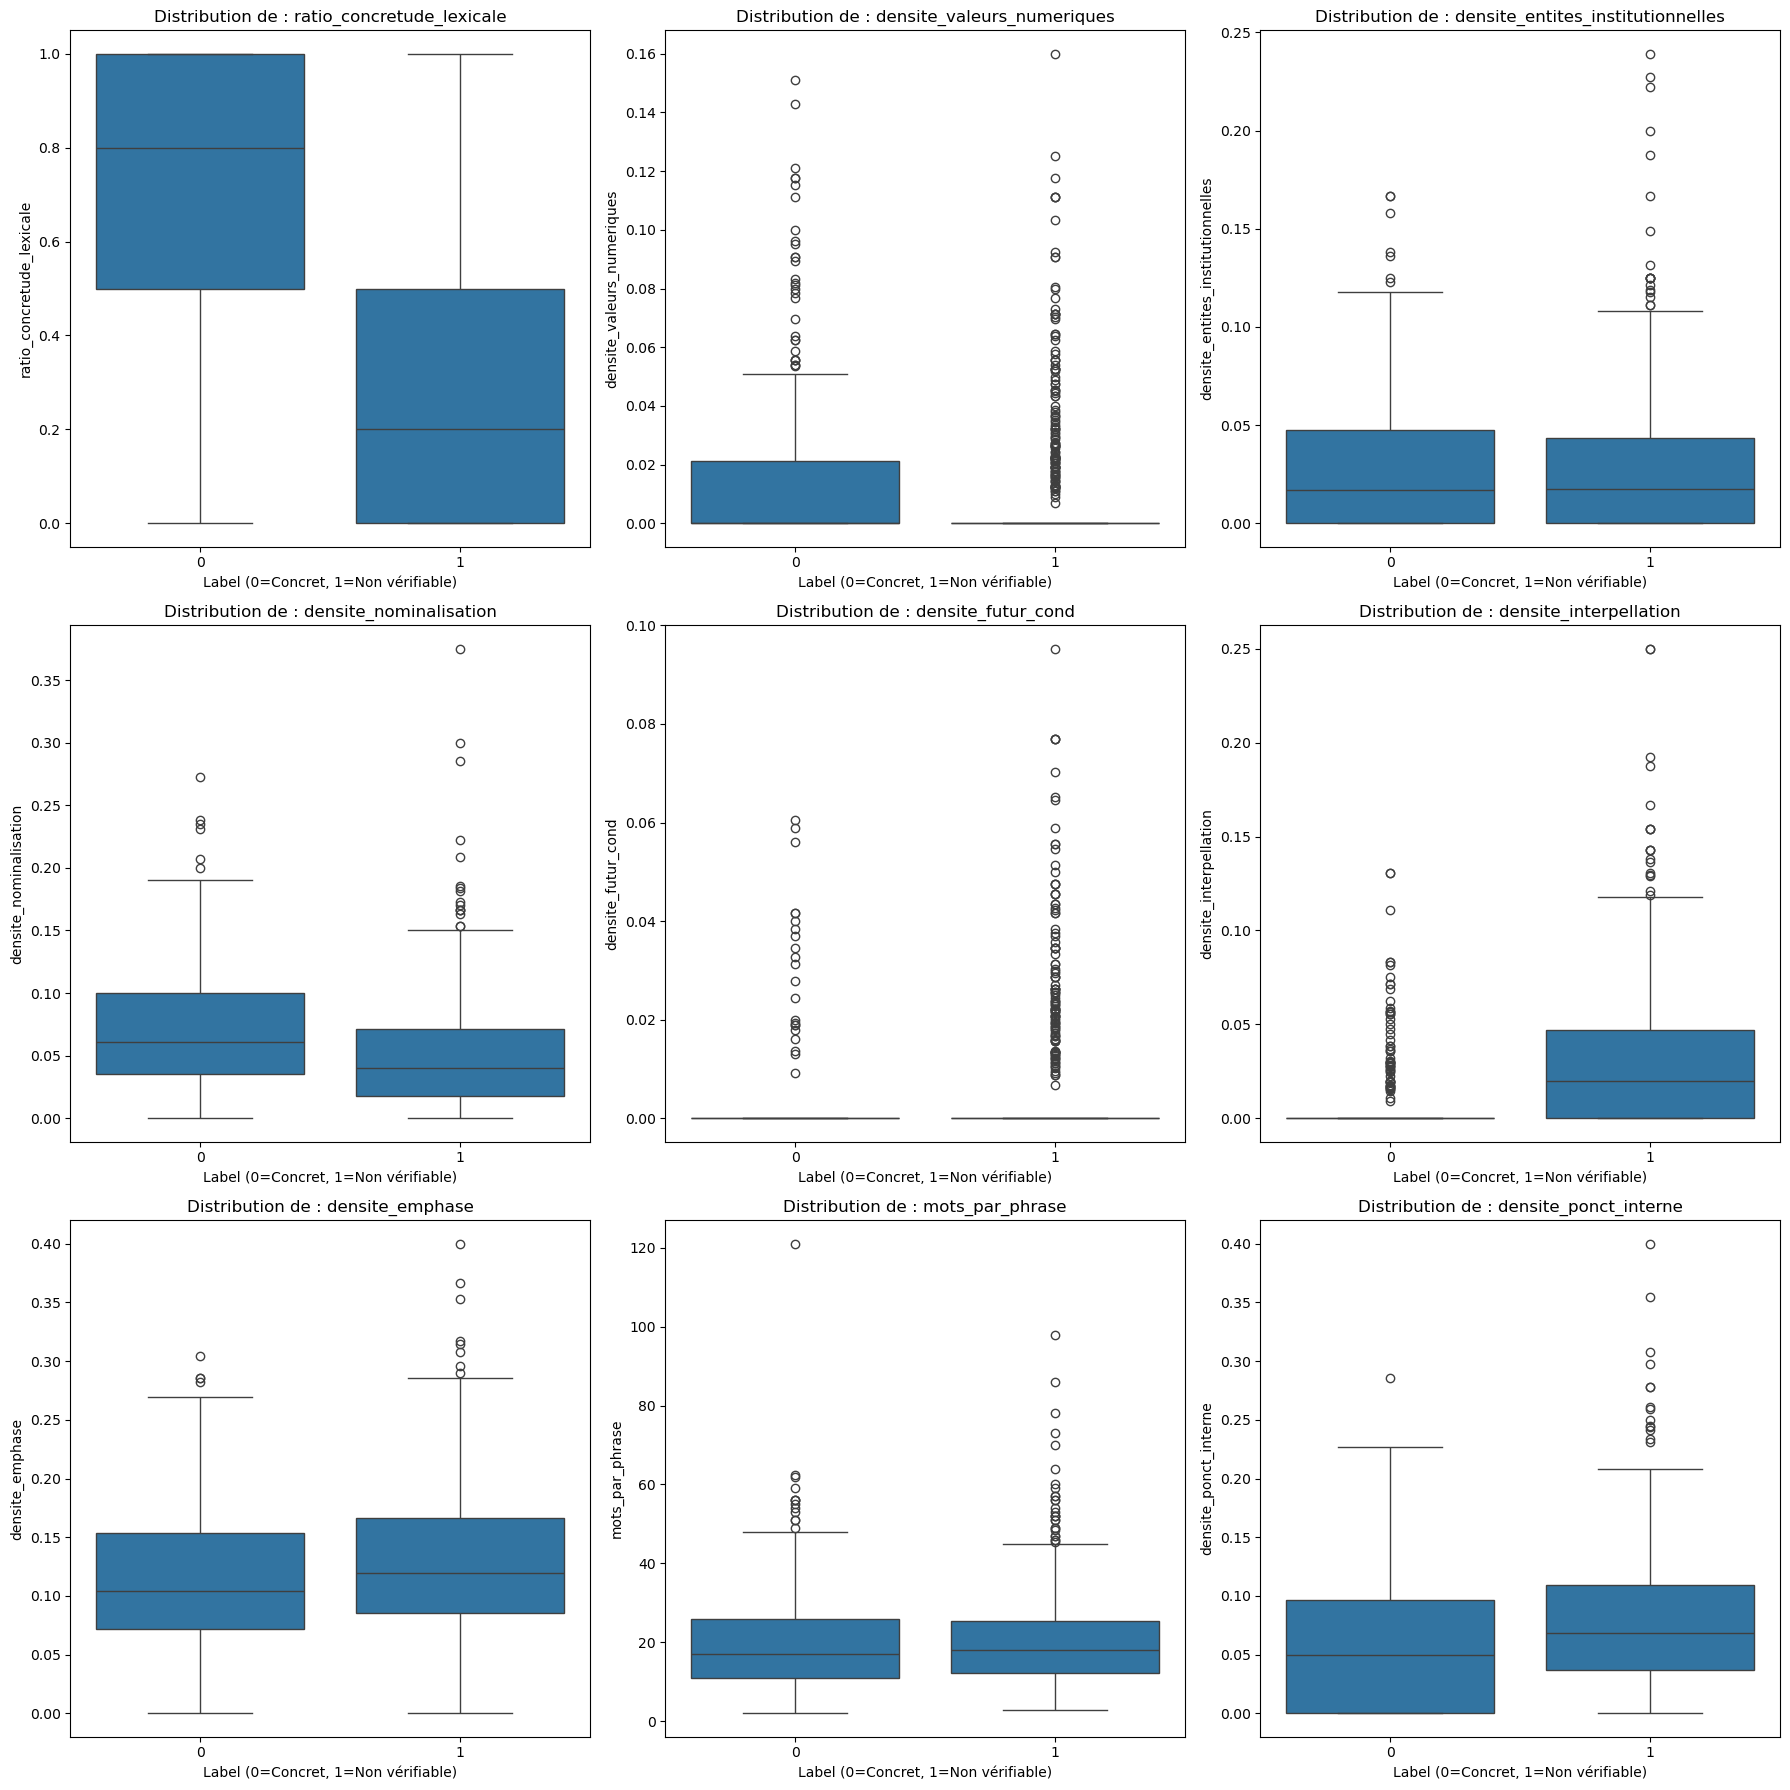

In [354]:

features_a_plotter = [
    'ratio_concretude_lexicale', 
    "densite_valeurs_numeriques",
        "densite_entites_institutionnelles",
        "densite_nominalisation",
        "densite_futur_cond",
        "densite_interpellation",
        "densite_emphase",
        "mots_par_phrase",
        "densite_ponct_interne"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

for i, feature in enumerate(features_a_plotter):
    sns.boxplot(
        data=df_train, 
        x='Label', 
        y=feature, 
        ax=axes[i]
        # palette={0: "lightblue", 1: "lightsalmon"}
    )
    axes[i].set_title(f"Distribution de : {feature}")
    axes[i].set_xlabel("Label (0=Concret, 1=Non vérifiable)")

plt.tight_layout()
plt.show()

À partir des boxplots ci-dessus, nous pouvons constater que :

1- Il existe de nombreux outliers : on va donc windsoriser les données pour limiter l'impact des outliers. On ne peut pas appliquer de logscale aux données ici car les valeurs sont proches de zero. On va  aussi utiliser RobustScaler (qqui scale les données avec la médiane et l'ecart interquartile au lieu de la moyenne et la std).


2- les features qui semblent avoir un pouvoir discriminant entre les deux classes sont: 
- ratio_concretude_lexicale: c'est normal au vu de la façon dont on a défini ce feature; mais pour que ce feature ait un vrai pouvoir discriminatif, il faut qu'il fonctionne aussi out-of-sample, ie que les mots fréquents dans chaque classe dans le train set soient aussi fréquents dans le test set.
- densite_valeurs_numériques: la densité de valeurs numériques est plus élevée dans la classe 0. Ce n'est pas une observation triviale car on observe un certain nombre de textes de la classe 1 qui contiennent des valeurs numériques (par exemple "10 millions d'étrangers" qui revient souvent dans les textes du FN) sans que le texte ne propose de choses concrètes. 
- densite_nominalisation: très étonnamment, il y a plus de mots se finissant par des suffixes d'abstraction de type "-tion, -ité, -isme, -ment" dans la classe 0, alors qu'on s'attendait à observer l'inverse
- densite_interpellation: les textes qui interpellent beaucoup le lecteur avec des pronoms de type "nous, vous" sont plus à même d'être des textes réthoriques et d'être en classe 1. 

Dans une moindre mesure: 
- densite_emphase: les textes qui contiennent un grand nombre d'adverbes par rapport au nombre de mots dans la phrase sont plus susceptibles d'être en classe 1, car ils témoignent d'un usage d'envolées lyriques et de réthorique dans le texte.
- densite_ponct_interne: de même, les textes avec beaucoup de ponctuation interne sont plus susceptibles d'être en classe 1, car les phrases avec beaucoup de ponctuation sont plus longues et souvent plus réthoriques.

On va donc clipper au quantile 99 les valeurs extremes sur certaines variables.

In [355]:
colonnes_a_winsoriser = ['mots_par_phrase', 'densite_ponct_interne','densite_futur_cond']

# 2. Appliquer la winsorisation (Plafonnement au 99e centile)
for col in colonnes_a_winsoriser:
    # On calcule la limite haute sur le Train
    seuil_max = df_train[col].quantile(0.99)
    
    # On écrête (clip) les valeurs supérieures à ce seuil
    df_train[col] = np.clip(df_train[col], a_min=None, a_max=seuil_max)
    df_test[col] = np.clip(df_test[col], a_min=None, a_max=seuil_max)

## E) Colinearité des features

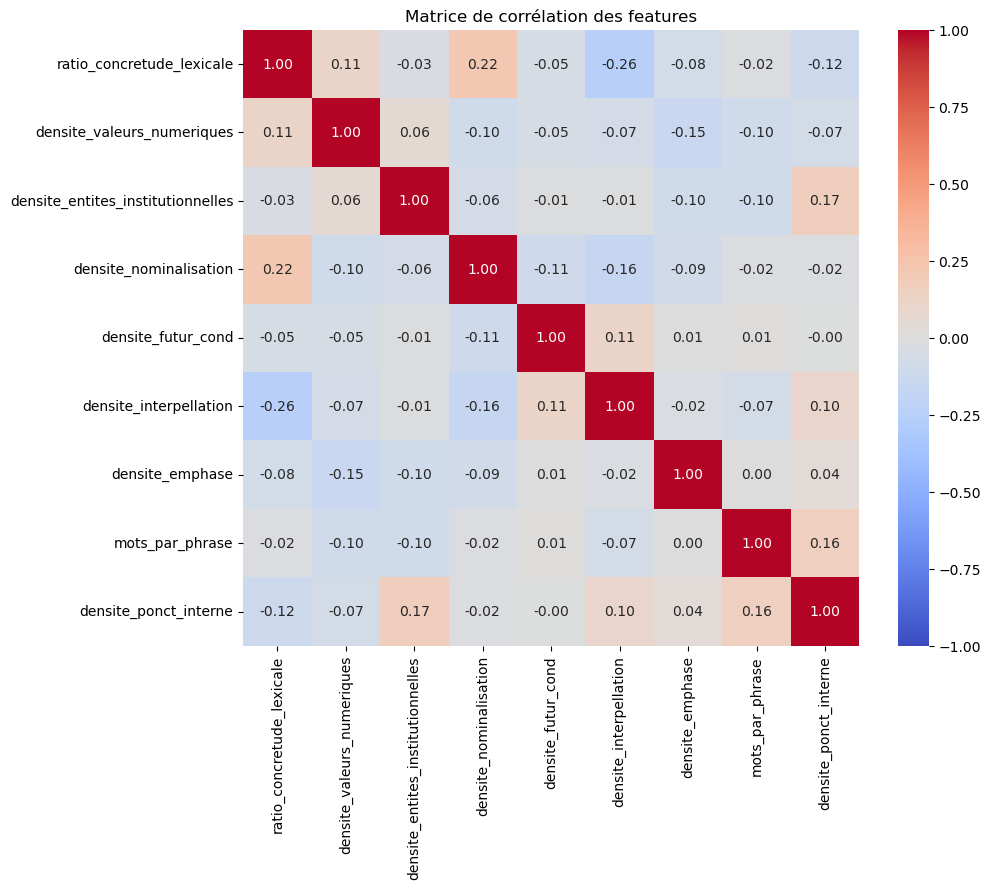

In [356]:
features_numeriques = df_train[features_a_plotter]

plt.figure(figsize=(10, 8))
matrice_corr = features_numeriques.corr()

# Masque pour ne pas afficher la partie supérieure (redondante)
# import numpy as np
# mask = np.triu(np.ones_like(matrice_corr, dtype=bool))

sns.heatmap(
    matrice_corr,  
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    square=True
)
plt.title("Matrice de corrélation des features")
plt.show()

Par chance, les features sont très peu corrélés entre eux et non colinéaires.

## F) Tests statistiques

On applique un test de Mann-Whitney sur chaque feature. Il s'agit d'un test non paramétrique et évalue si les deux échantillons (classe 0 et 1) proviennent de la même population/distribution ayant la même médiane (le test quantifie la probabilité qu'une observation tirée au hasard dans un groupe soit plus grande qu'une observation tirée au hasard dans l'autre.)

In [357]:
for feat in features_a_plotter:
# Test sur la densité NER
    groupe_0 = df_train[df_train['Label'] == 0][feat]
    groupe_1 = df_train[df_train['Label'] == 1][feat]

    stat, p_value = mannwhitneyu(groupe_0, groupe_1)
    print(f"P-value du test Mann-Whitney pour {feat} : {round(float(p_value),3)}")

P-value du test Mann-Whitney pour ratio_concretude_lexicale : 0.0
P-value du test Mann-Whitney pour densite_valeurs_numeriques : 0.012
P-value du test Mann-Whitney pour densite_entites_institutionnelles : 0.759
P-value du test Mann-Whitney pour densite_nominalisation : 0.0
P-value du test Mann-Whitney pour densite_futur_cond : 0.0
P-value du test Mann-Whitney pour densite_interpellation : 0.0
P-value du test Mann-Whitney pour densite_emphase : 0.017
P-value du test Mann-Whitney pour mots_par_phrase : 0.369
P-value du test Mann-Whitney pour densite_ponct_interne : 0.0


Tous les features ont une p-value <0.05 mis à part mots_par_phrase et densite_entites_institutionnelles, donc on va se débarasser de ces features et conserver les autres.


In [358]:
df_train = df_train.drop(columns = ['densite_entites_institutionnelles','mots_par_phrase'])
df_test = df_test.drop(columns = ['densite_entites_institutionnelles','mots_par_phrase'])

## G) Analyse des données par orientation politique 


Chaque texte annoté a été associé à son parti politique et à une orientation politique parmi les suivantes: "gauche radicale, gauche, centre, droite, droite radicale".

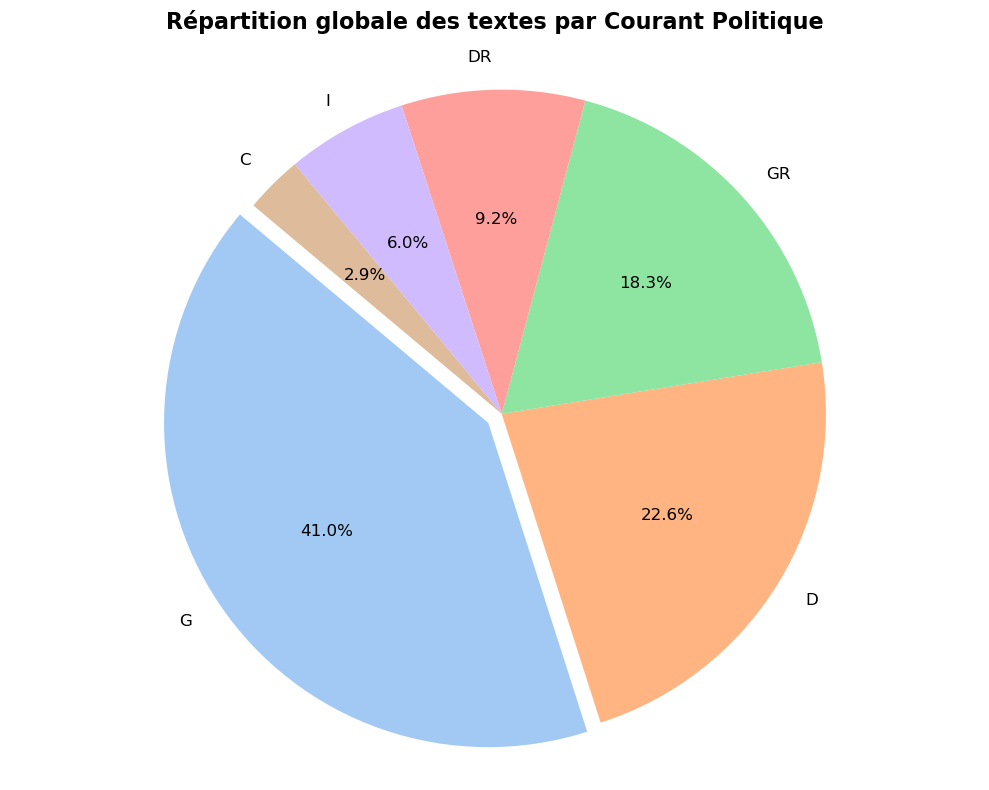

In [359]:
# 1. Calcul des volumes par courant politique
repartition = df_train['Courant Politique'].value_counts()

# 2. Paramétrage esthétique (Couleurs et mise en évidence)
# On utilise une palette Seaborn douce pour un rendu académique
couleurs = sns.color_palette('pastel')[0:len(repartition)]

# Optionnel : On "détache" la plus grosse part (le premier élément) pour la mettre en valeur
explosion = [0.05] + [0] * (len(repartition) - 1) 

# 3. Création du graphique
plt.figure(figsize=(10, 8))
plt.pie(
    repartition.values, 
    labels=repartition.index, 
    colors=couleurs, 
    explode=explosion,
    autopct='%1.1f%%', # Affiche les pourcentages avec 1 chiffre après la virgule
    startangle=140,    # Tourne le graphique pour une meilleure lisibilité
    shadow=False, 
    textprops={'fontsize': 12} # Taille du texte
)

# 4. Finalisation
plt.title("Répartition globale des textes par Courant Politique", fontsize=16, fontweight='bold', pad=20)
plt.axis('equal') # Garantit que le camembert est un cercle parfait (et non un ovale)

plt.tight_layout()
plt.show()

La majorité des textes provient de gauche, de droite et de gauche radicale et les textes de ces orientations poltiques représentent plus de 82% des textes disponibles. 

On dispose de peu d'échantillons provenant de droite radicale, du centre et des indépendants (partis inclassifiables sur l'échiquier politique traditionnel) car les partis associés y sont marginaux en 1990. 

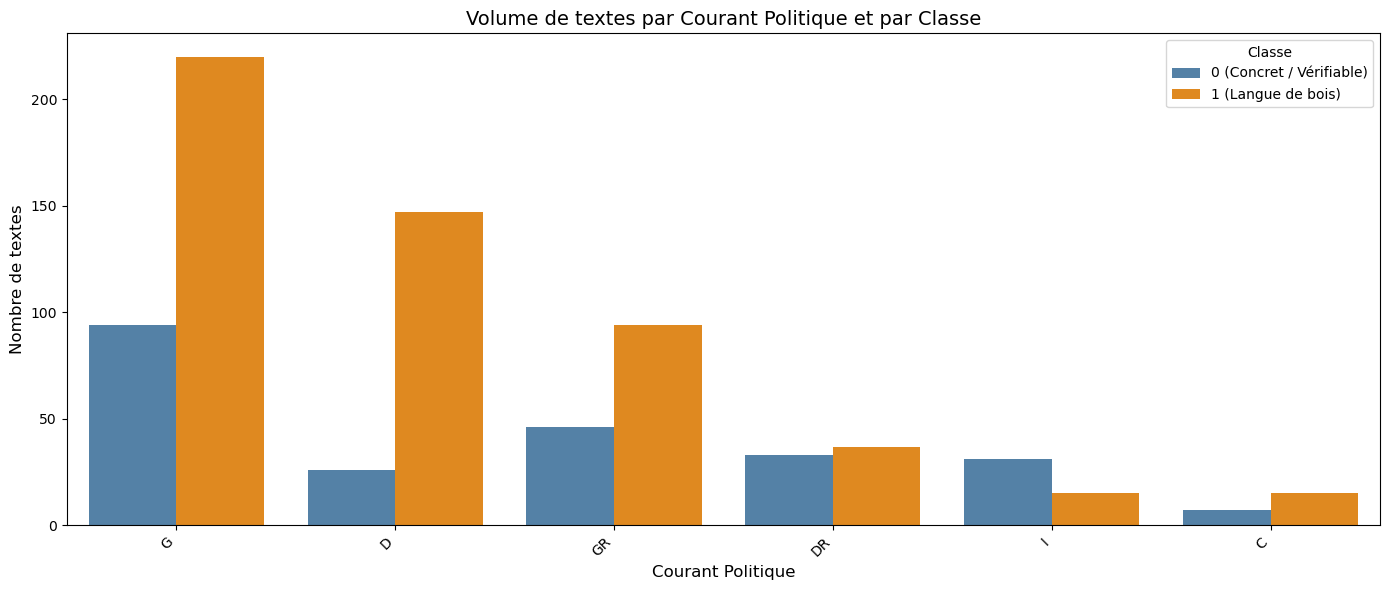

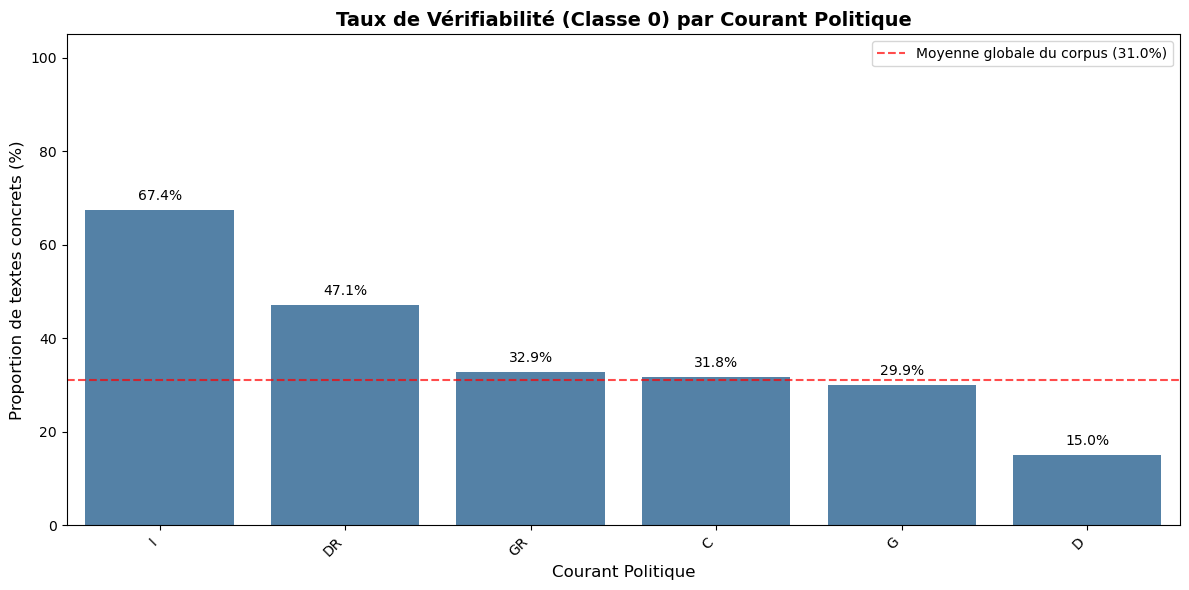

In [360]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# On définit la palette de couleurs pour rester cohérent avec tes précédents graphiques
couleurs = {0: "steelblue", 1: "darkorange"}
labels_legend = ['0 (Concret / Vérifiable)', '1 (Langue de bois)']

# --- GRAPHIQUE 1 : Les Volumes Absolus (Countplot) ---
# Utile pour voir si ton dataset est déséquilibré selon les courants
plt.figure(figsize=(14, 6))
ax1 = sns.countplot(
    data=df_train, 
    x='Courant Politique', 
    hue='Label', 
    palette=couleurs,
    order=df_train['Courant Politique'].value_counts().index # Trie du plus grand au plus petit courant
)
plt.title("Volume de textes par Courant Politique et par Classe", fontsize=14)
plt.xlabel("Courant Politique", fontsize=12)
plt.ylabel("Nombre de textes", fontsize=12)
plt.legend(title='Classe', labels=labels_legend)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# --- GRAPHIQUE 2 : Les Proportions Relatives (100% Stacked Bar Chart) ---
# LE PLUS IMPORTANT : Mesure la propension à la langue de bois indépendamment du volume

# 1. Calcul du tableau croisé dynamique avec normalisation par ligne ('index')
cross_tab_prop = pd.crosstab(
    df_train['Courant Politique'], 
    df_train['Label'], 
    normalize='index'
) * 100 # Multiplié par 100 pour l'avoir en pourcentages


# 1. Calcul rigoureux du pourcentage de Classe 0 par courant politique
taux_concret = (
    df_train[df_train['Label'] == 0].groupby('Courant Politique').size() / 
    df_train.groupby('Courant Politique').size() * 100
).fillna(0)

# 2. Tri décroissant pour transformer le graphique en classement
taux_concret = taux_concret.sort_values(ascending=False).reset_index(name='Pourcentage')

# 3. Création du graphique en barres simples
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=taux_concret, 
    x='Courant Politique', 
    y='Pourcentage', 
    color='steelblue' # Conservation de ta couleur associée à la Classe 0
)

# 4. Ajout des annotations (affichage du % exact au-dessus de chaque barre)
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%', 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        color='black', 
        xytext=(0, 5), 
        textcoords='offset points'
    )

# 5. Ajout de la moyenne globale du Train set comme ligne de référence (Baseline)
moyenne_globale = (df_train['Label'] == 0).mean() * 100
plt.axhline(
    moyenne_globale, 
    color='red', 
    linestyle='--', 
    alpha=0.7, 
    label=f'Moyenne globale du corpus ({moyenne_globale:.1f}%)'
)

# Formatage final
plt.title("Taux de Vérifiabilité (Classe 0) par Courant Politique", fontsize=14, fontweight='bold')
plt.ylabel("Proportion de textes concrets (%)", fontsize=12)
plt.xlabel("Courant Politique", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 105) # Espace supplémentaire pour les annotations
plt.legend()
plt.tight_layout()

plt.show()



On voit que les partis ayant le pourcentage de textes vérifiables selon notre dataset sont les indépendants (I) et la droite radicale (DR); en revanche, on dispose de peu de textes pour ces courants politiques donc ce n'est peut-être pas très représentatifs. 

On voit ensuite que la gauche radicale (GR), le centre (C) et la gauche (G) sont dans la moyenne. Enfin, la droite (D) est en dernière avec une proportion de textes vérifiables deux fois inférieure à la moyenne.

worldcloud contrastif pour l'orientation GR


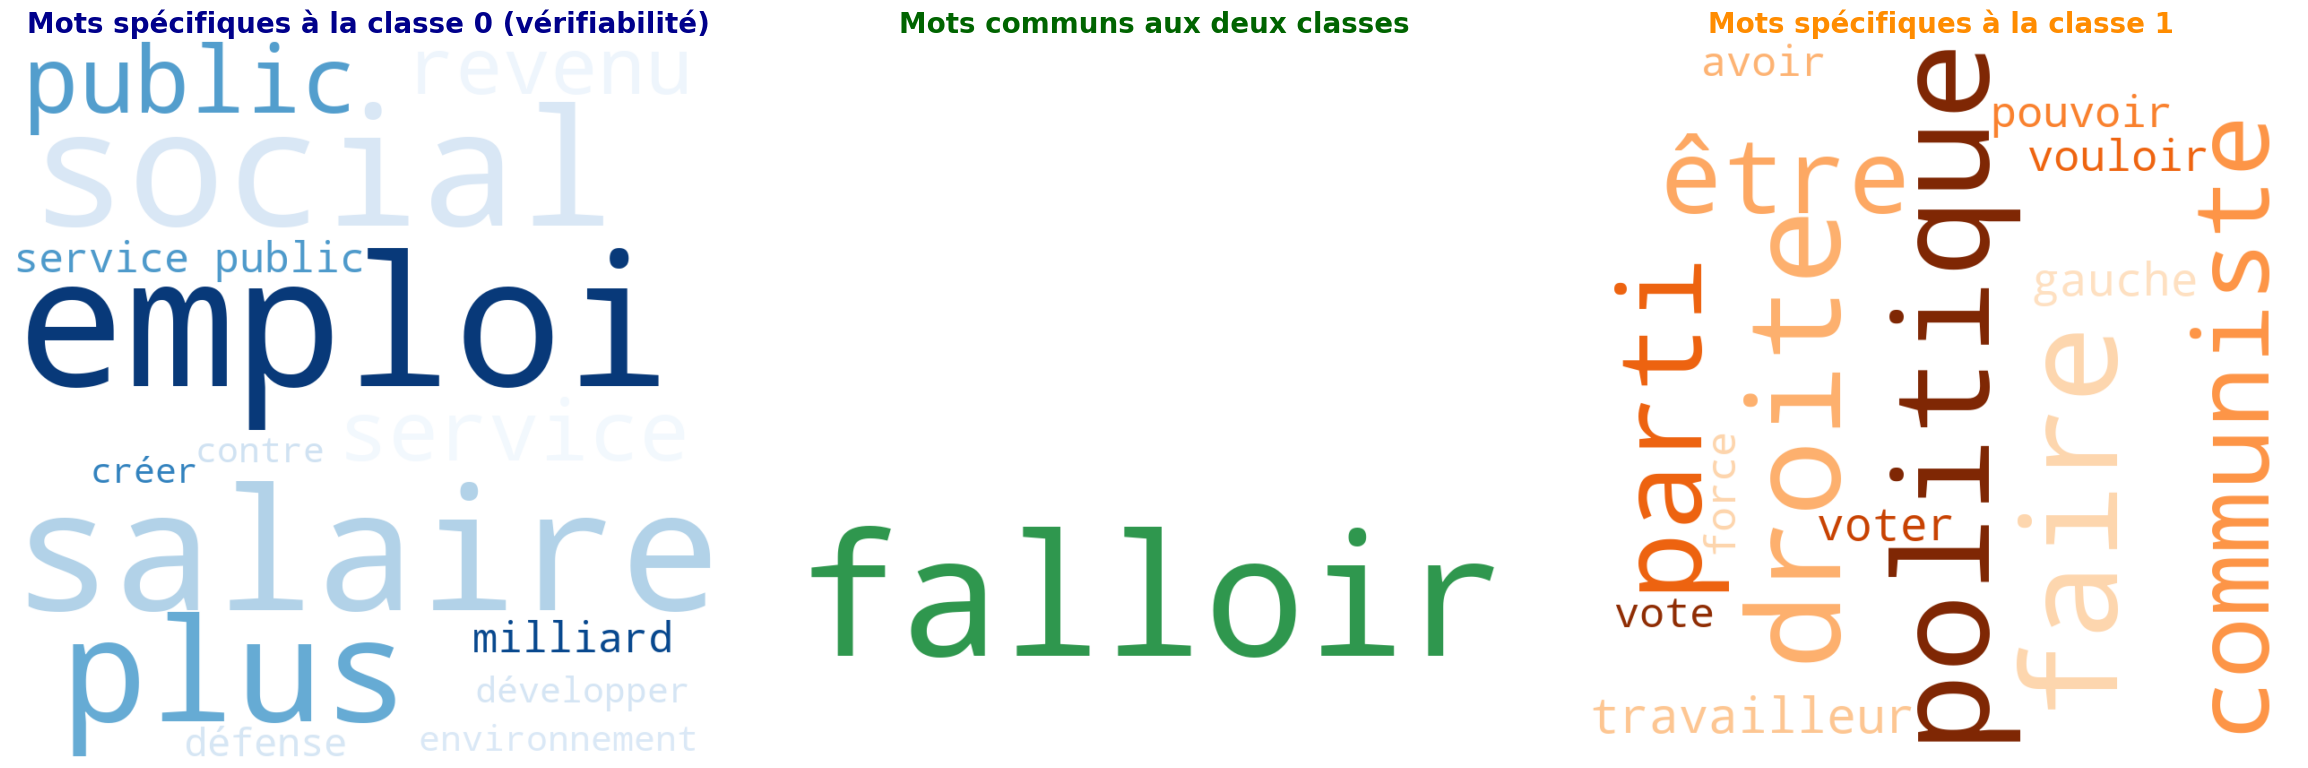

worldcloud contrastif pour l'orientation G


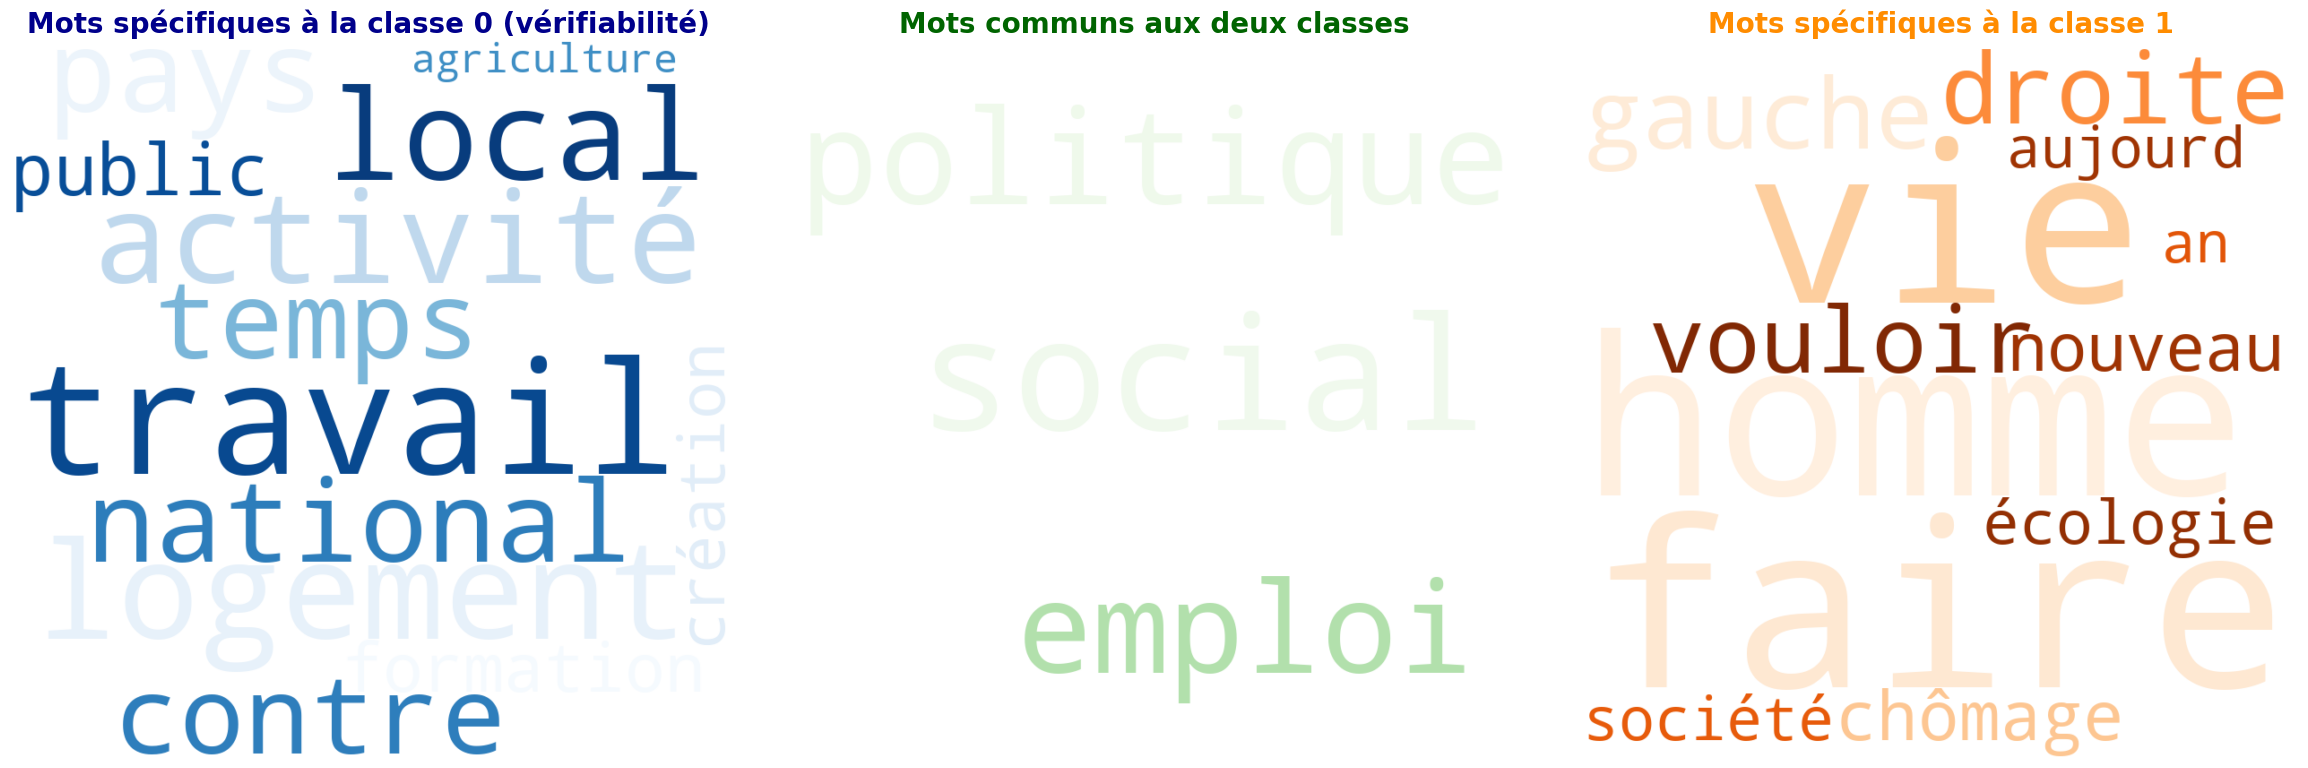

worldcloud contrastif pour l'orientation C


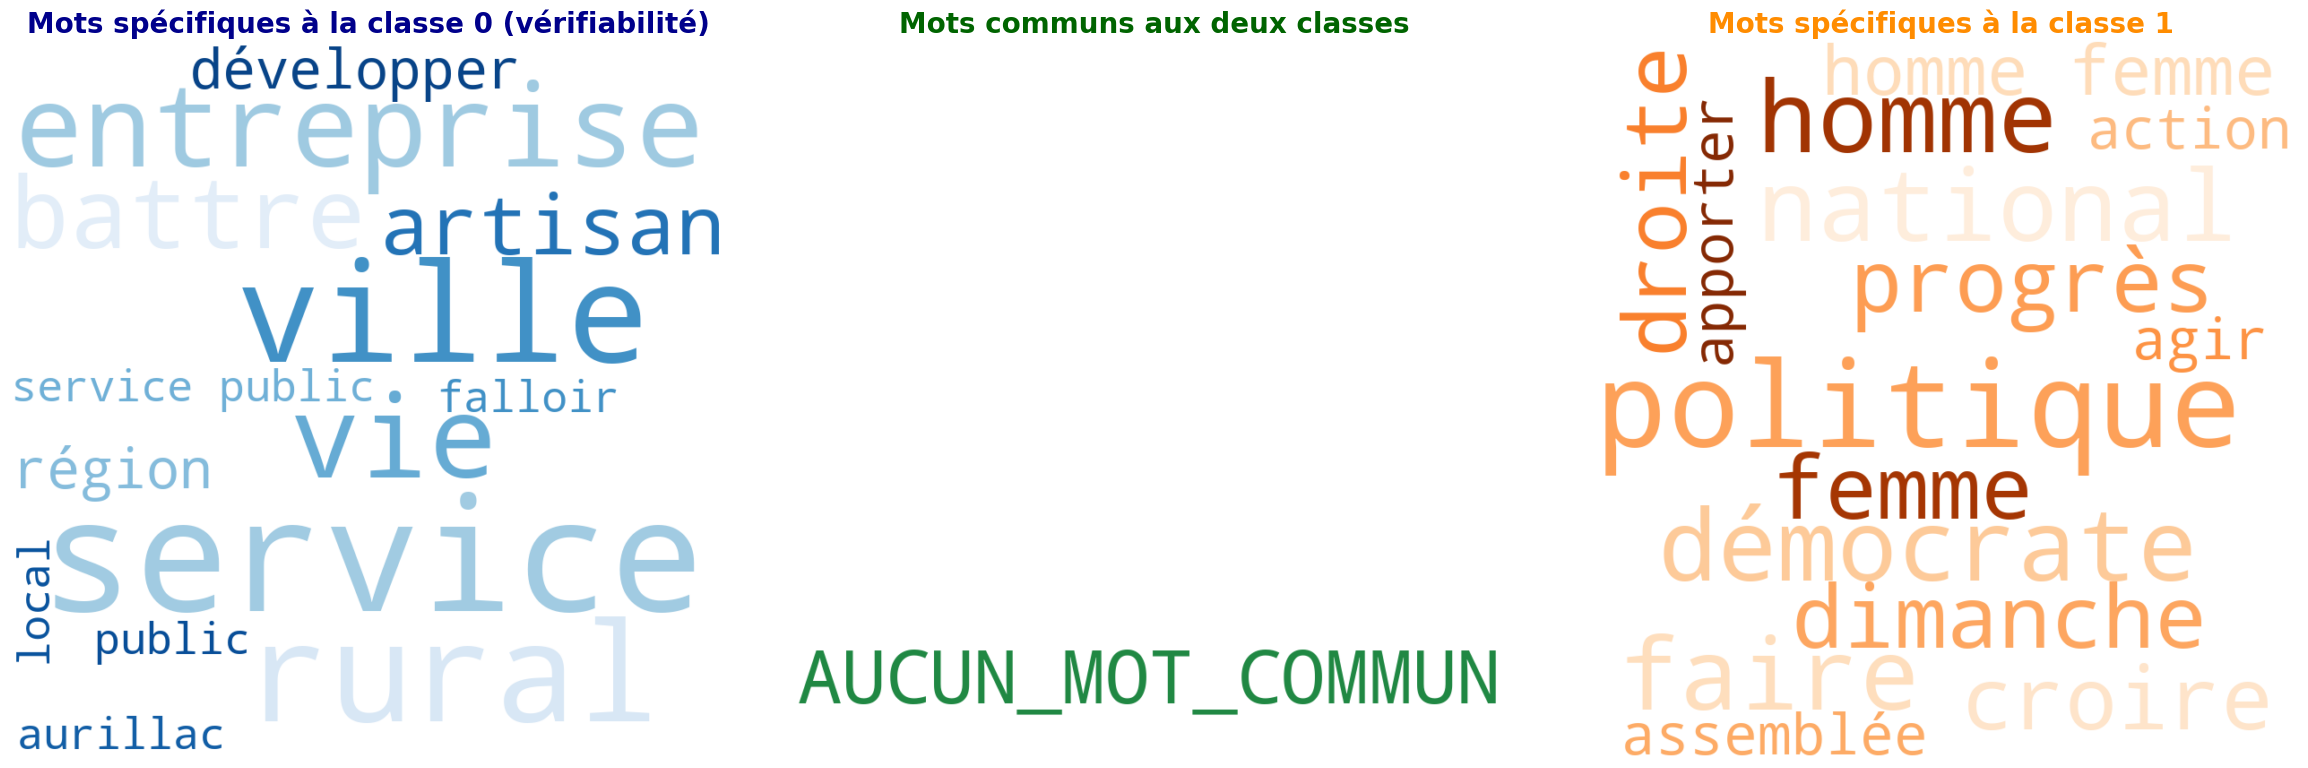

worldcloud contrastif pour l'orientation D


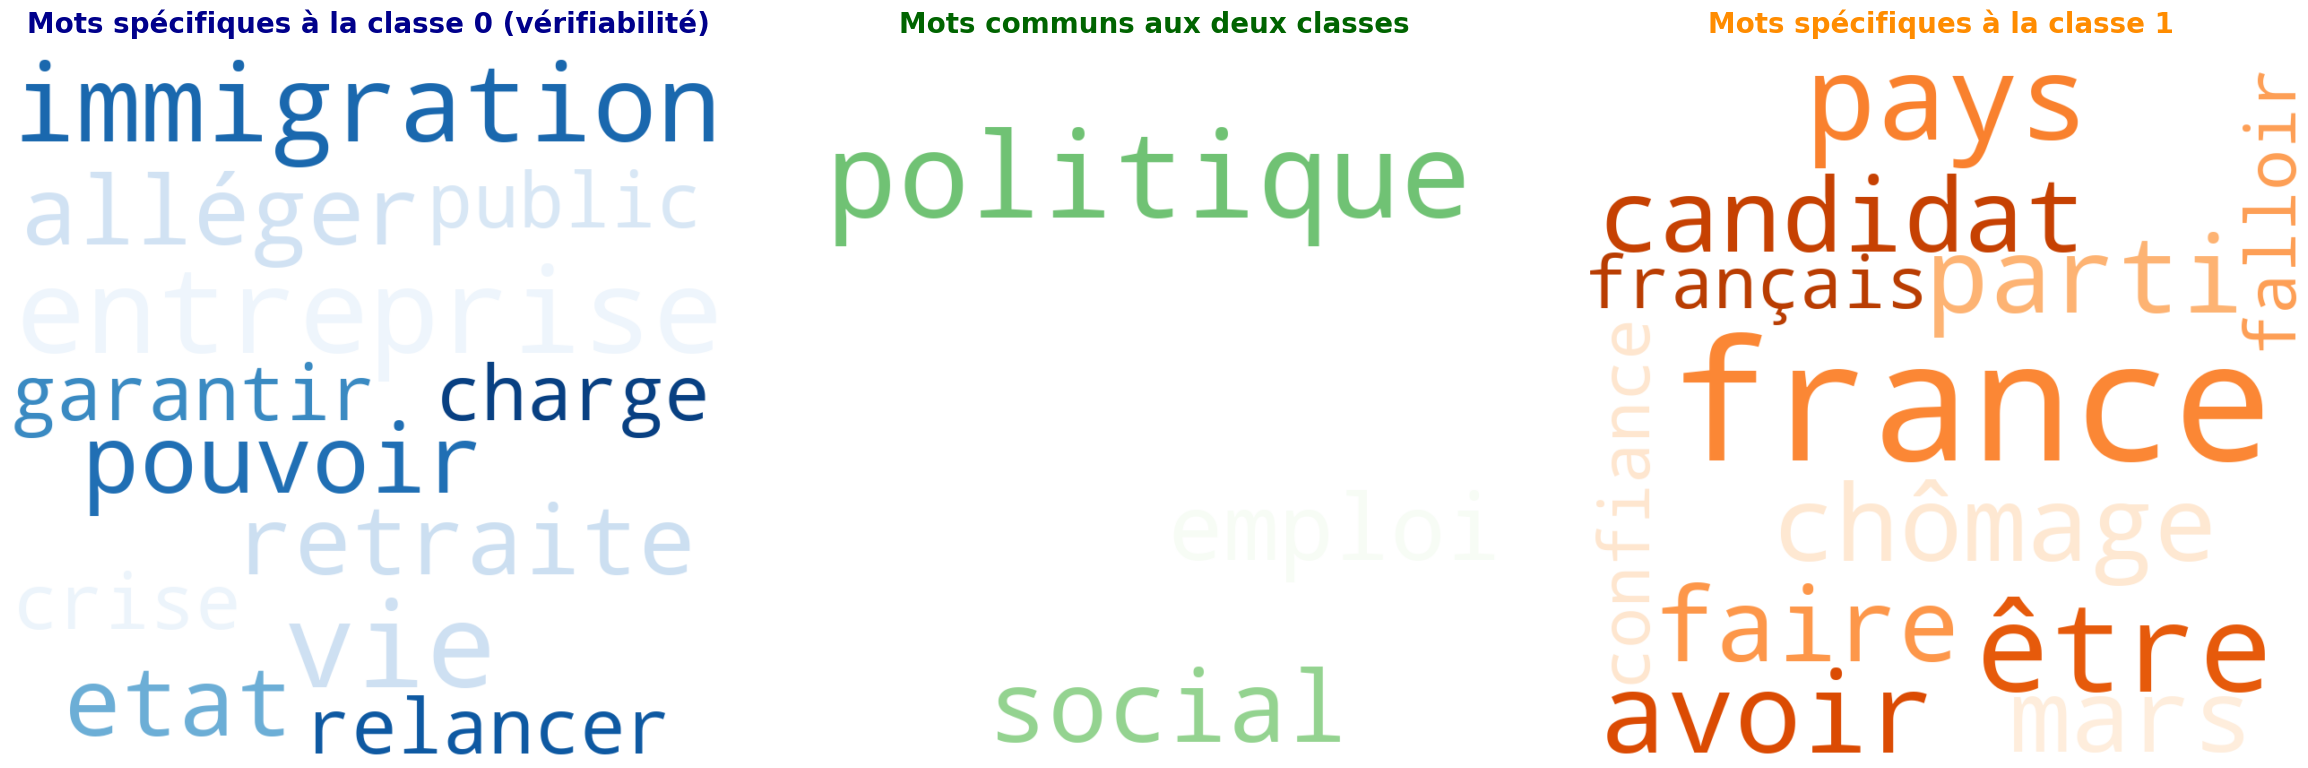

worldcloud contrastif pour l'orientation DR


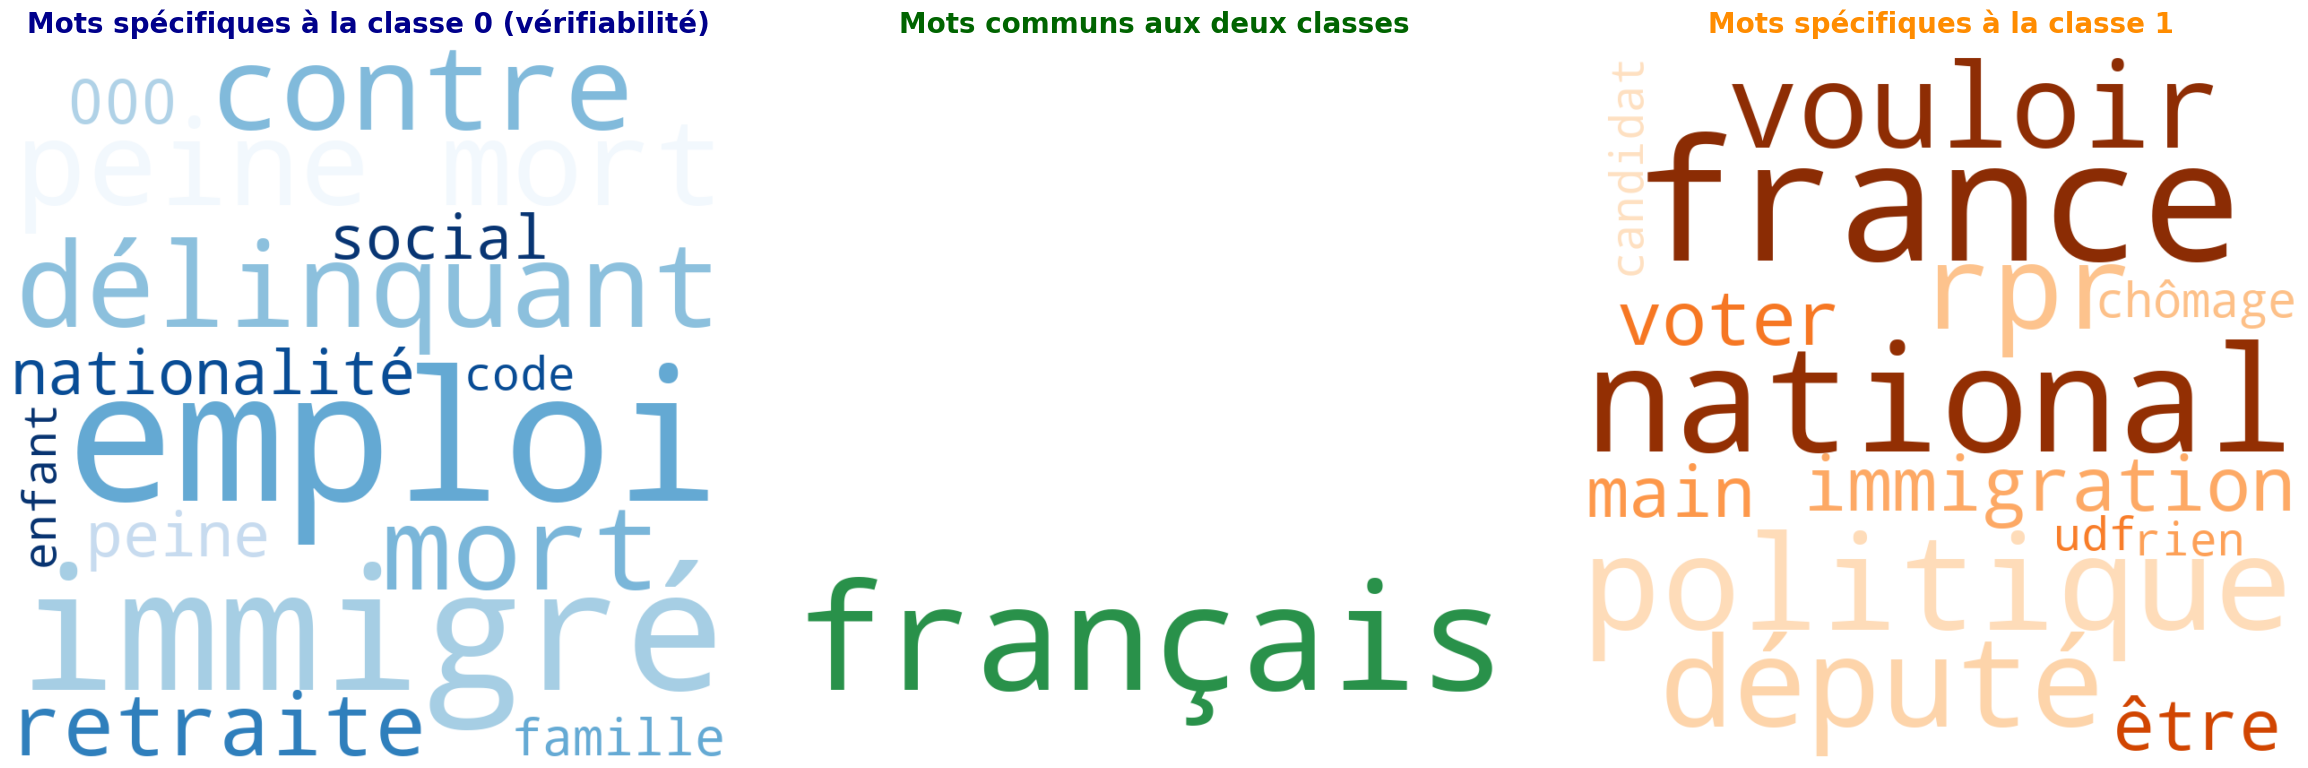

In [361]:
for orientation in ['GR','G','C','D','DR']:
    print(f"worldcloud contrastif pour l'orientation {orientation}")
    plot_wordclouds_contrastifs(df_train[df_train['Courant Politique']==orientation], top_n=15)

Dans les mots associés à la classe "vérifiable" pour chaque parti, on retrouve des thèmes chers à chaque parti:
- à gauche et à la gauche radicale: "salaire", "service public", "activité", "logement", "social", ...
- à droite et à la droite radicale: "immigration", "entreprise", "retraite", "alléger", ... 
Dans les mots associés à la classe 1, on retrouve encore le vocabulaire de la campagne. 


# II- Entrainement de modèles linéaires baselines

## A) Pipeline

On va utiliser l'embedding TF-IDF pour convertir le texte (qu'on a au préalable nettoyé et lemmatisé) en features:
- On va extraire le texte en bigrammes et en unigrammes. On n'utilise pas de trigrammes car on n'a pas assez de textes, donc on risquerait d'avoir trop de features et d'overfit. 
- On va supprimer les mots qui apparaissent dans moins de 5 textes (par exemple les noms de villages ou de candidats locaux car ils ne servent à rien et risquent juste de faire overfit les données)
- idem, on va supprimer les mots qui apparaissent dans plus de 85% des textes car ce sont probablement des stop-words spécifiques au corpus (eg poltiique, France, pays, etc) qui sont utilisés à la fois en classe 0 et 1 et n'apportent aucune information.

On va utiliser RobustScaler sur les features numériques qu'on a créé car ils présentent un certain nombre d'outliers donc standardiser avec la médiane et l'IQR permettra de limiter l'impact des outliers.

Comme il n'y a que 31% de texte de la classe 0, on va pondérer la loss sur les datapoints de la classe 0 par des pondérations plus élevées. 

In [ ]:
colonne_texte = 'texte_lemmatise'

colonnes_numeriques = [
    'ratio_concretude_lexicale', 
    "densite_valeurs_numeriques",
        "densite_nominalisation",
        "densite_interpellation",
        "densite_emphase",
        "densite_ponct_interne"
]

#pipeline 
preprocesseur = ColumnTransformer(
    transformers=[
        ('texte', TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.95), colonne_texte),
        ('num', RobustScaler(), colonnes_numeriques)
    ],
    remainder='drop' # On ignore les autres colonnes
)

X_train_transforme = preprocesseur.fit_transform(df_train)

# 2. On affiche les dimensions
print("Dimensions de X après preprocessing :", X_train_transforme.shape)



Dimensions de X après preprocessing : (765, 1501)


Après preprocessing, n et p sont du même ordre de grandeur donc il faut absolument régulariser pour éviter de complètement overfit nos données. 

## B) Régression logistique

On va faire une cross-validation pour entrainer le meilleur modèle de régression logistique possible; On va utiliser une validation croisée stratifiée avec 10 folds (permet de s'assurer que la proportion de textes de chaque classe est identique dans chaque set utilisé pour la cross val).

On va optimiser notre modèle selon la métrique F1_score car les proportions des deux classes sont déséquilibrées;

In [412]:
clf = LogisticRegression(max_iter=3000, random_state=42, class_weight='balanced', solver='liblinear')

pipeline_lr = Pipeline(steps=[
    ('preprocesseur', preprocesseur),
    ('modele', clf)
])

# 2. Définition de la Grille de Paramètres
param_grid = {
    'modele__C': [1,2.5,5,7.5, 10, 12.5, 15],
    'modele__penalty': ['l1', 'l2']
}

# 3. Configuration de la validation croisée stratifiée
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 4. Initialisation du GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1', # Métrique robuste pour l'équilibre des classes
    n_jobs=-1,          # Utilisation de tous les processeurs
    verbose=1
)

grid_search.fit(df_train, df_train['Label'])

# 5. Résultats
print(f"Meilleurs paramètres : {grid_search.best_params_}")

# 6. Évaluation sur le jeu de test avec le meilleur estimateur
meilleur_modele_logreg = grid_search.best_estimator_
y_pred = meilleur_modele_logreg.predict(df_test)

print("Performance finale de la régression logistique sur le test dataset :")
print(classification_report(df_test['Label'], y_pred))

Fitting 10 folds for each of 14 candidates, totalling 140 fits
Meilleurs paramètres : {'modele__C': 12.5, 'modele__penalty': 'l2'}
Performance finale de la régression logistique sur le test dataset :
              precision    recall  f1-score   support

           0       0.66      0.75      0.70        60
           1       0.88      0.83      0.85       132

    accuracy                           0.80       192
   macro avg       0.77      0.79      0.78       192
weighted avg       0.81      0.80      0.81       192



In [404]:
confusion_matrix(df_test['Label'], y_pred,normalize='true')

array([[0.75      , 0.25      ],
       [0.17424242, 0.82575758]])

In [414]:
print("Performance finale du benchmark constant sur le test dataset :")
print(classification_report(np.ones(len(df_test['Label'])), y_pred))

print("confusion matrix benchmark constant")
confusion_matrix(np.ones(len(df_test['Label'])), y_pred,normalize='true')

Performance finale du benchmark constant sur le test dataset :
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         0
         1.0       1.00      0.65      0.78       192

    accuracy                           0.65       192
   macro avg       0.50      0.32      0.39       192
weighted avg       1.00      0.65      0.78       192

confusion matrix benchmark constant


c:\Users\jean-\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jean-\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jean-\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


array([[0.        , 0.        ],
       [0.35416667, 0.64583333]])

Analyse des résultats:
- La cross validation permet de choisir une pénalisation L2 plutot que L1. Cela signifie que la langue de bois dans le corpus n'est pas définie par quelques mots clés, mais plutôt par une combinaison de centaines de termes.
- Le score F1 global est de 0.78. On bat donc clairement le benchmark constant (qui ne prédit que des 1) car son score F1 global est de 0.39.
- le modèle a un taux de faux positifs de 25%, et de faux négatifs de 17%.

## C) Linear SVM


In [408]:
pipeline_svc = Pipeline(steps=[
    ('preprocesseur', preprocesseur),
    ('modele', LinearSVC(class_weight='balanced', max_iter=3000, random_state=42))
])

# 2. La Grille de recherche conditionnelle (Évite les erreurs de compatibilité mathématique)
param_grid_svc = [
    # Grille 1 : Si on utilise la pénalité L2 (Standard)
    # Puisque n < p (765 < 1500), on utilise le solveur Dual
    {
        'modele__C': [0.1, 0.5,0.75,1,1.25,1.5,1.75],
        'modele__penalty': ['l2'],
        'modele__dual': [True]
    },
    # Grille 2 : Si on veut tester la sélection de variables (L1)
    # La pénalité L1 exige obligatoirement dual=False
    {
        'modele__C': [0.01, 0.1, 1],
        'modele__penalty': ['l1'],
        'modele__dual': [False]
    }
]

# 3. Validation Croisée Stratifiée
cv_stratified = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 4. Configuration du GridSearchCV
grid_search_svc = GridSearchCV(
    estimator=pipeline_svc,
    param_grid=param_grid_svc,
    cv=cv_stratified,
    scoring='f1', 
    n_jobs=-1,          
    verbose=1
)


grid_search_svc.fit(df_train, df_train['Label'])

# 5. Extraction et affichage des résultats
print("Meilleurs hyperparamètres SVM :", grid_search_svc.best_params_)
print(f"Meilleur score F1 : {grid_search_svc.best_score_:.3f}")

# 6. Évaluation finale sur le set de Test
meilleur_svc = grid_search_svc.best_estimator_
y_pred_svc = meilleur_svc.predict(df_test)

print("performance finale sur le test dataset")
print(classification_report(df_test['Label'], y_pred_svc))

print("confusion matrix")
confusion_matrix(df_test['Label'], y_pred_svc,normalize='true')

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Meilleurs hyperparamètres SVM : {'modele__C': 1, 'modele__dual': True, 'modele__penalty': 'l2'}
Meilleur score F1 : 0.855
performance finale sur le test dataset
              precision    recall  f1-score   support

           0       0.66      0.75      0.70        60
           1       0.88      0.83      0.85       132

    accuracy                           0.80       192
   macro avg       0.77      0.79      0.78       192
weighted avg       0.81      0.80      0.81       192

confusion matrix


array([[0.75      , 0.25      ],
       [0.17424242, 0.82575758]])

On obtient des résultats quasiment identiques entre SVM linéaire et régression logistique. Encore une fois, la cross validation choisit la pénalisation L2 ce qui confirme notre observation précédente.

## D) Random Forest

In [418]:


pipeline_rf = Pipeline(steps=[
    ('preprocesseur', preprocesseur),
    ('modele', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_grid_rf = {
    'modele__n_estimators': [200,300,400,500],           
    'modele__max_depth': [5,10, 15,20],      
    'modele__min_samples_leaf': [1, 2, 4],           # samples minimum par feuille finale
    'modele__max_features': ['sqrt', 'log2']         # Nombre de variables tirées au sort par nœud
}

# 3. Validation Croisée Stratifiée
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Configuration du GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    cv=cv_stratified,
    scoring='f1', 
    n_jobs=-1,          
    verbose=1
)

grid_search_rf.fit(df_train, df_train['Label'])

print("Meilleurs hyperparamètres RF :", grid_search_rf.best_params_)

# 6. Évaluation finale sur le set de Test
meilleur_rf = grid_search_rf.best_estimator_
y_pred_rf = meilleur_rf.predict(df_test)

print("Performance finale (Random Forest)")
print(classification_report(df_test['Label'], y_pred_rf))

# Affichage de la matrice normalisée
print("confusion matrix")
print(confusion_matrix(df_test['Label'], y_pred_rf, normalize='true'))

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Meilleurs hyperparamètres RF : {'modele__max_depth': 15, 'modele__max_features': 'log2', 'modele__min_samples_leaf': 1, 'modele__n_estimators': 300}
Performance finale (Random Forest)
              precision    recall  f1-score   support

           0       0.60      0.80      0.69        60
           1       0.89      0.76      0.82       132

    accuracy                           0.77       192
   macro avg       0.75      0.78      0.75       192
weighted avg       0.80      0.77      0.78       192

confusion matrix
[[0.8        0.2       ]
 [0.24242424 0.75757576]]


On obtient des résultats légèrement moins bons avec la random forest: son score F1 global est de 0.75 ce qui est moins satisfaisant que pour les autres modèles.




# III- Entrainement de transformers

# IV- Application du meilleur modèle à des données out-of-sample 
## A) Création du dataset out-of-sample: choix de règles sur comment on découpe les textes en datapoints 
## B) Analyse des résultats